# OrganAMNIST Ensemble Study, Evaluation and Plots

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, precision_score, recall_score, f1_score,
                              average_precision_score, log_loss)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility of meta-learner
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## Configuration

In [2]:
DATASET = 'organamnist'  # Change to: 'bloodmnist', 'breastmnist', 'dermamnist', 'organamnist'

# Dataset-specific configuration
DATASET_CONFIG = {
    'bloodmnist':   {'n_classes': 8,  'figure_number': 3},
    'breastmnist':  {'n_classes': 2,  'figure_number': 4},
    'dermamnist':   {'n_classes': 7,  'figure_number': 5},
    'organamnist':  {'n_classes': 11, 'figure_number': 6},
}

n_classes = DATASET_CONFIG[DATASET]['n_classes']
FIGURE_NUMBER = DATASET_CONFIG[DATASET]['figure_number']

INPUT_DIR = f"./{DATASET}_outputs"  
OUTPUT_DIR = f"./{DATASET}_results"  
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class names mapping
CLASS_NAMES_MAP = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature granulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}

CLASS_NAMES_MAP_4CM = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature \ngranulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}
CLASS_NAMES = CLASS_NAMES_MAP[DATASET]
CLASS_NAMES_4CM = CLASS_NAMES_MAP_4CM[DATASET]

# Meta-learner hyperparameters
DROPOUT_META = 0.5
META_BATCH_SIZE = 16
META_EPOCHS = 50
META_PATIENCE = 5

print(f"Dataset: {DATASET}")
print(f"Number of classes: {n_classes}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset: organamnist
Number of classes: 11
Input directory: ./organamnist_outputs
Output directory: ./organamnist_results


## Load Predictions and Ground Truth

In [3]:
import medmnist
from medmnist import INFO

INDIVIDUAL_MODELS = ['ConvNeXtBase', 'ViT-Base', 'EfficientNetV2M', 'InceptionResNetV2']

def get_or_create_labels(split, primary_name, alternate_names, input_dir, dataset):
    primary_path = f"{input_dir}/{primary_name}"
    if os.path.exists(primary_path):
        labels = np.load(primary_path).flatten()
        print(f"  Loaded {split} labels from {primary_name} ({len(labels)} samples)")
        return labels
    for fname in alternate_names:
        p = f"{input_dir}/{fname}"
        if os.path.exists(p):
            labels = np.load(p).flatten()
            np.save(primary_path, labels)
            print(f"  Loaded {split} labels from {fname} and saved as {primary_name}")
            return labels
    print(f"  {primary_name} not found - reconstructing from MedMNIST...")
    info = INFO[dataset]
    DataClass = getattr(medmnist, info['python_class'])
    data = DataClass(split=split, download=True, size=28)
    labels = data.labels.flatten()
    np.save(primary_path, labels)
    print(f"  Saved {primary_name} ({len(labels)} samples)")
    return labels


print("Loading predictions...")
test_preds = {}
val_preds = {}
for m in INDIVIDUAL_MODELS:
    test_preds[m] = np.load(f"{INPUT_DIR}/{m}_test_preds.npy")
    val_preds[m] = np.load(f"{INPUT_DIR}/{m}_val_preds.npy")
    print(f"  {m}: test {test_preds[m].shape}, val {val_preds[m].shape}")

print("\nChecking for NaN in predictions...")
nan_found = False
for m in INDIVIDUAL_MODELS:
    mask_test = np.any(np.isnan(test_preds[m]), axis=1)
    mask_val = np.any(np.isnan(val_preds[m]), axis=1)
    if mask_test.sum() > 0:
        print(f"  Repairing {mask_test.sum()} NaN row(s) in {m} test predictions")
        test_preds[m][mask_test] = 1.0 / n_classes
        nan_found = True
    if mask_val.sum() > 0:
        print(f"  Repairing {mask_val.sum()} NaN row(s) in {m} val predictions")
        val_preds[m][mask_val] = 1.0 / n_classes
        nan_found = True
if not nan_found:
    print("  All predictions clean.")

print(f"\nLoading ground truth labels for {DATASET}...")
y_true_flat = get_or_create_labels(
    'test', 'y_true_flat.npy', ['y_test_true.npy'], INPUT_DIR, DATASET
)
y_val_flat = get_or_create_labels(
    'val', 'y_val_flat.npy', ['y_val_true.npy'], INPUT_DIR, DATASET
)

y_true_cat = to_categorical(y_true_flat, n_classes)
y_val_cat = to_categorical(y_val_flat, n_classes)

print(f"\nTest samples: {len(y_true_flat)}")
print(f"Val samples:  {len(y_val_flat)}")

Loading predictions...
  ConvNeXtBase: test (17778, 11), val (6491, 11)
  ViT-Base: test (17778, 11), val (6491, 11)
  EfficientNetV2M: test (17778, 11), val (6491, 11)
  InceptionResNetV2: test (17778, 11), val (6491, 11)

Checking for NaN in predictions...
  All predictions clean.

Loading ground truth labels for organamnist...
  y_true_flat.npy not found - reconstructing from MedMNIST...


100%|██████████| 38.2M/38.2M [01:56<00:00, 327kB/s] 


  Saved y_true_flat.npy (17778 samples)
  y_val_flat.npy not found - reconstructing from MedMNIST...
  Saved y_val_flat.npy (6491 samples)

Test samples: 17778
Val samples:  6491


## Soft Voting Ensemble

In [4]:
print("="*70)
print("SOFT VOTING ENSEMBLE")
print("="*70)

soft_voting_probs = np.mean(np.array(list(test_preds.values())), axis=0)
np.save(f"{OUTPUT_DIR}/SoftVoting_test_preds.npy", soft_voting_probs)

acc = accuracy_score(y_true_flat, np.argmax(soft_voting_probs, axis=1))
print(f"Soft Voting Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/SoftVoting_test_preds.npy")

SOFT VOTING ENSEMBLE
Soft Voting Accuracy: 0.9857
Saved to: ./organamnist_results/SoftVoting_test_preds.npy


## Rigorous Stacking Ensemble

In [5]:
print("="*70)
print("RIGOROUS STACKING ENSEMBLE")
print("="*70)

# Build meta-training input from validation predictions
X_meta_train = np.concatenate([val_preds[m] for m in INDIVIDUAL_MODELS], axis=1)
X_meta_test = np.concatenate([test_preds[m] for m in INDIVIDUAL_MODELS], axis=1)

print(f"Meta-train shape: {X_meta_train.shape}")
print(f"Meta-test shape: {X_meta_test.shape}")

def build_meta_learner(input_dim, n_classes):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(DROPOUT_META)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='Meta_Learner')

meta_model = build_meta_learner(X_meta_train.shape[1], n_classes)
meta_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

meta_model.fit(X_meta_train, y_val_cat,
               epochs=META_EPOCHS, batch_size=META_BATCH_SIZE,
               validation_split=0.1,
               callbacks=[callbacks.EarlyStopping(patience=META_PATIENCE, restore_best_weights=True)],
               verbose=1)

meta_model.save(f"{OUTPUT_DIR}/MetaLearner_{DATASET}.keras")
stacking_probs = meta_model.predict(X_meta_test, verbose=0)
np.save(f"{OUTPUT_DIR}/RigorousStacking_test_preds.npy", stacking_probs)

acc = accuracy_score(y_true_flat, np.argmax(stacking_probs, axis=1))
print(f"\nRigorous Stacking Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/RigorousStacking_test_preds.npy")

RIGOROUS STACKING ENSEMBLE
Meta-train shape: (6491, 44)
Meta-test shape: (17778, 44)
Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8747 - loss: 0.6363 - val_accuracy: 0.9969 - val_loss: 0.0103
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0257 - val_accuracy: 0.9985 - val_loss: 0.0048
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9990 - loss: 0.0115 - val_accuracy: 0.9985 - val_loss: 0.0017
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9995 - loss: 0.0066 - val_accuracy: 0.9985 - val_loss: 0.0020
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0047 - val_accuracy: 0.9985 - val_loss: 0.0021
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 1.1376e-04
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9997 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 2.0924e-05
Epoch 8/50


## Analysis Helper Functions

In [6]:
def print_confusion_matrix_table(cm, class_names, model_name):
    """Prints confusion matrix as a labeled pandas DataFrame."""
    cm_df = pd.DataFrame(cm,
                         index=[f"True_{c}" for c in class_names],
                         columns=[f"Pred_{c}" for c in class_names])
    print(f"\n--- {model_name} Confusion Matrix (Table) ---")
    print(cm_df.to_string())
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"\n--- Per-Class Recall ---")
    for i, c in enumerate(class_names):
        print(f"  Class {i} ({c}): {per_class_acc[i]:.4f} ({cm[i, i]}/{cm[i].sum()})")
    return cm_df


def analyze_entropy_peaks(entropy_correct, entropy_wrong, model_name,
                          n_points=1000):
    """
    Returns the single highest peak (mode) for correct and incorrect distributions.
    """
    if len(entropy_correct) < 2 or len(entropy_wrong) < 1:
        print(f"\n--- {model_name} ---\nInsufficient data for KDE")
        return None
    
    x_min = 0
    x_max = max(entropy_correct.max(), entropy_wrong.max()) + 0.1
    x_grid = np.linspace(x_min, x_max, n_points)
    
    # KDE for correct distribution - take global maximum
    kde_correct = gaussian_kde(entropy_correct)
    density_correct = kde_correct(x_grid)
    peak_correct_idx = int(np.argmax(density_correct))
    peak_correct_x = float(x_grid[peak_correct_idx])
    peak_correct_y = float(density_correct[peak_correct_idx])
    
    # KDE for wrong distribution - take global maximum
    if len(entropy_wrong) >= 2:
        kde_wrong = gaussian_kde(entropy_wrong)
        density_wrong = kde_wrong(x_grid)
        peak_wrong_idx = int(np.argmax(density_wrong))
        peak_wrong_x = float(x_grid[peak_wrong_idx])
        peak_wrong_y = float(density_wrong[peak_wrong_idx])
    else:
        # Edge case: single wrong sample
        density_wrong = np.zeros(n_points)
        peak_wrong_x = float(entropy_wrong[0])
        peak_wrong_y = 0.0
    
    print(f"\n--- {model_name} Entropy Distribution Analysis ---")
    print(f"Correct: n={len(entropy_correct)}, "
          f"mean={entropy_correct.mean():.4f}, "
          f"median={np.median(entropy_correct):.4f}, "
          f"std={entropy_correct.std():.4f}")
    print(f"Wrong:   n={len(entropy_wrong)}, "
          f"mean={entropy_wrong.mean():.4f}, "
          f"median={np.median(entropy_wrong):.4f}, "
          f"std={entropy_wrong.std():.4f}")
    
    print(f"\nHighest correct peak: entropy={peak_correct_x:.4f}, height={peak_correct_y:.4f}")
    print(f"Highest wrong peak:   entropy={peak_wrong_x:.4f}, height={peak_wrong_y:.4f}")
    
    return {
        'x_grid': x_grid.tolist(),
        'density_correct': density_correct.tolist(),
        'density_wrong': density_wrong.tolist(),
        'peaks_correct_x': [peak_correct_x],
        'peaks_correct_y': [peak_correct_y],
        'peaks_wrong_x': [peak_wrong_x],
        'peaks_wrong_y': [peak_wrong_y],
    }


def analyze_reliability_pairs(probs, y_pred, y_true, model_name, n_bins=10):
    is_correct = (y_pred == y_true).astype(int)
    pred_conf = np.max(probs, axis=1)
    
    prob_true, prob_pred = calibration_curve(is_correct, pred_conf, n_bins=n_bins, strategy='quantile')
    
    bins = np.quantile(pred_conf, np.linspace(0, 1, n_bins+1))
    bin_counts = []
    for i in range(len(bins)-1):
        mask = (pred_conf >= bins[i]) & (pred_conf <= bins[i+1])
        bin_counts.append(int(mask.sum()))
    
    print(f"\n--- {model_name} Reliability Diagram (Numerical) ---")
    print(f"{'Bin':<5} {'Confidence':<15} {'Accuracy':<15} {'Gap':<15} {'n_samples':<10}")
    print("-" * 65)
    for i in range(len(prob_pred)):
        gap = prob_pred[i] - prob_true[i]
        n = bin_counts[i] if i < len(bin_counts) else 0
        print(f"{i+1:<5} {prob_pred[i]:<15.4f} {prob_true[i]:<15.4f} {gap:<15.4f} {n:<10}")
    
    valid_counts = bin_counts[:len(prob_pred)]
    if sum(valid_counts) > 0:
        ece = np.sum(np.abs(np.array(prob_pred) - np.array(prob_true)) *
                     np.array(valid_counts) / sum(valid_counts))
    else:
        ece = 0
    print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
    
    return {
        'confidence': prob_pred.tolist(),
        'accuracy': prob_true.tolist(),
        'gap': (prob_pred - prob_true).tolist(),
        'bin_counts': bin_counts,
        'ece': float(ece)
    }


def compute_all_metrics(probs, y_true_flat, y_true_cat, model_name):
    y_pred = np.argmax(probs, axis=1)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true_flat, y_pred),
        'AUC_macro': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='macro'),
        'AUC_weighted': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='weighted'),
        'Precision_macro': precision_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Precision_weighted': precision_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Recall_weighted': recall_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_true_cat, probs, average='macro'),
        'PR_AUC_weighted': average_precision_score(y_true_cat, probs, average='weighted'),
        'Log_Loss': log_loss(y_true_cat, probs)
    }

##  Master Evaluation Function

In [7]:
def to_json_safe(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj


def evaluate_model(probs, y_true_flat, y_true_cat, model_name, class_names, class_names_4cm, color='Blues'):
    print(f"\n{'='*70}\nEVALUATION: {model_name}\n{'='*70}")
    
    y_pred = np.argmax(probs, axis=1)
    
    # 1. Metrics
    metrics = compute_all_metrics(probs, y_true_flat, y_true_cat, model_name)
    print("\n--- Comprehensive Metrics ---")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k}: {v:.4f}")
    
    # 2. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true_flat, y_pred, target_names=class_names, digits=4))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_true_flat, y_pred)
    print_confusion_matrix_table(cm, class_names, model_name)
    
    # 4. Entropy Analysis 
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct_mask = (y_pred == y_true_flat)
    entropy_analysis = analyze_entropy_peaks(
        entropy[correct_mask], entropy[~correct_mask], model_name
    )
    
    # 5. Reliability Analysis
    reliability = analyze_reliability_pairs(probs, y_pred, y_true_flat, model_name)
    
    # 6. Diagnostic Plots WITH peak markers shown
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[0],
                xticklabels=class_names_4cm, yticklabels=class_names_4cm)
    axes[0].set_title(f'{model_name} CM (Acc: {metrics["Accuracy"]:.2%})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', labelsize=6)
    axes[0].tick_params(axis='y', labelsize=6)
    plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center', rotation_mode='anchor')
    
    # Entropy Distribution WITH peak markers
    sns.kdeplot(entropy[correct_mask], label=f'Correct (n={correct_mask.sum()})',
                fill=True, color='#2166AC', ax=axes[1])
    sns.kdeplot(entropy[~correct_mask], label=f'Wrong (n={(~correct_mask).sum()})',
                fill=True, color='#D97B00', ax=axes[1])
    
    if entropy_analysis:
        for px, py in list(zip(entropy_analysis['peaks_correct_x'],
                                entropy_analysis['peaks_correct_y']))[:3]:
            axes[1].axvline(px, color='#2166AC', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, color='#2166AC')
        for px, py in list(zip(entropy_analysis['peaks_wrong_x'],
                                entropy_analysis['peaks_wrong_y']))[:3]:
            axes[1].axvline(px, color='#D97B00', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, -15), textcoords='offset points',
                           fontsize=8, color='#D97B00')
    
    axes[1].set_title(f'{model_name} Entropy')
    axes[1].set_xlabel('Shannon Entropy')
    axes[1].legend()
    
    # Reliability Diagram
    axes[2].plot(reliability['confidence'], reliability['accuracy'],
                 marker='o', label=model_name, color='purple')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[2].set_title(f'{model_name} Reliability (ECE={reliability["ece"]:.4f})')
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save results
    results = {
        'metrics': {k: to_json_safe(v) for k, v in metrics.items()},
        'confusion_matrix': cm.tolist(),
        'entropy_analysis': entropy_analysis,
        'reliability': reliability
    }
    
    with open(f"{OUTPUT_DIR}/{model_name}_results.json", 'w') as f:
        json.dump(results, f, indent=2, default=to_json_safe)
    
    return results

## Evaluate All Models


EVALUATION: ConvNeXtBase

--- Comprehensive Metrics ---
  Accuracy: 0.9726
  AUC_macro: 0.9994
  AUC_weighted: 0.9992
  Precision_macro: 0.9751
  Precision_weighted: 0.9732
  Recall_macro: 0.9690
  Recall_weighted: 0.9726
  F1_macro: 0.9716
  F1_weighted: 0.9726
  PR_AUC_macro: 0.9960
  PR_AUC_weighted: 0.9956
  Log_Loss: 0.1095

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9734    0.9527    0.9629      1036
     femur-L     0.9922    0.9770    0.9846       784
     femur-R     0.9849    0.9899    0.9874       793
       heart     1.0000    0.9019    0.9484       785
    kidney-L     0.9082    0.9448    0.9261      2064
    kidney-R     0.9865    0.9313    0.9581      1965
       liver     1.0000    0.9893    0.9946      3285
      lung-L     0.9641    0.9994    0.9815      1747
      lung-R     0.9811    1.0000    0.9904      1813
    pancreas     0.9877    0.9938    0.9908      1622
      spleen     0.9480    0.9782    0.962

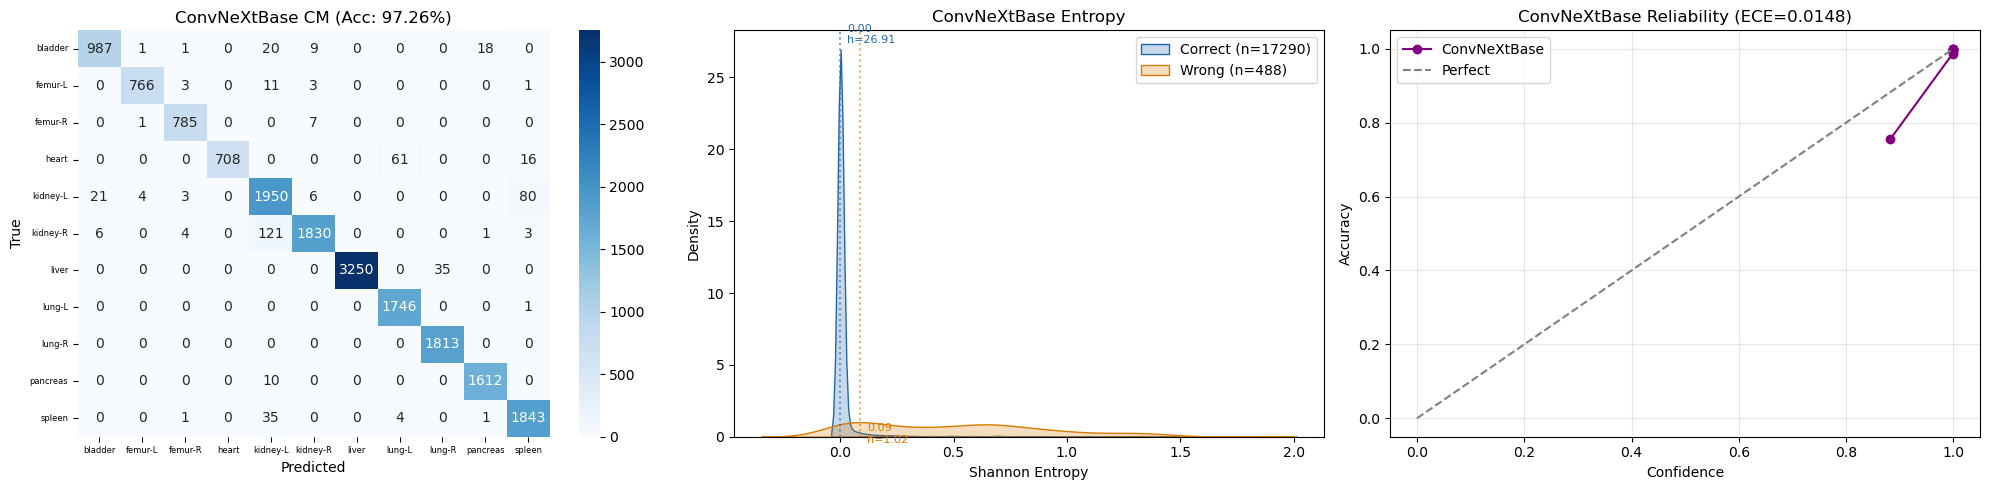


EVALUATION: ViT-Base

--- Comprehensive Metrics ---
  Accuracy: 0.9807
  AUC_macro: 0.9989
  AUC_weighted: 0.9987
  Precision_macro: 0.9814
  Precision_weighted: 0.9809
  Recall_macro: 0.9781
  Recall_weighted: 0.9807
  F1_macro: 0.9795
  F1_weighted: 0.9806
  PR_AUC_macro: 0.9937
  PR_AUC_weighted: 0.9931
  Log_Loss: 0.1448

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9859    0.9459    0.9655      1036
     femur-L     0.9895    0.9656    0.9774       784
     femur-R     0.9776    0.9924    0.9850       793
       heart     1.0000    0.9643    0.9818       785
    kidney-L     0.9682    0.9297    0.9486      2064
    kidney-R     0.9771    0.9761    0.9766      1965
       liver     0.9988    0.9939    0.9963      3285
      lung-L     0.9966    0.9994    0.9980      1747
      lung-R     0.9891    0.9989    0.9940      1813
    pancreas     0.9712    0.9963    0.9836      1622
      spleen     0.9409    0.9968    0.9680   

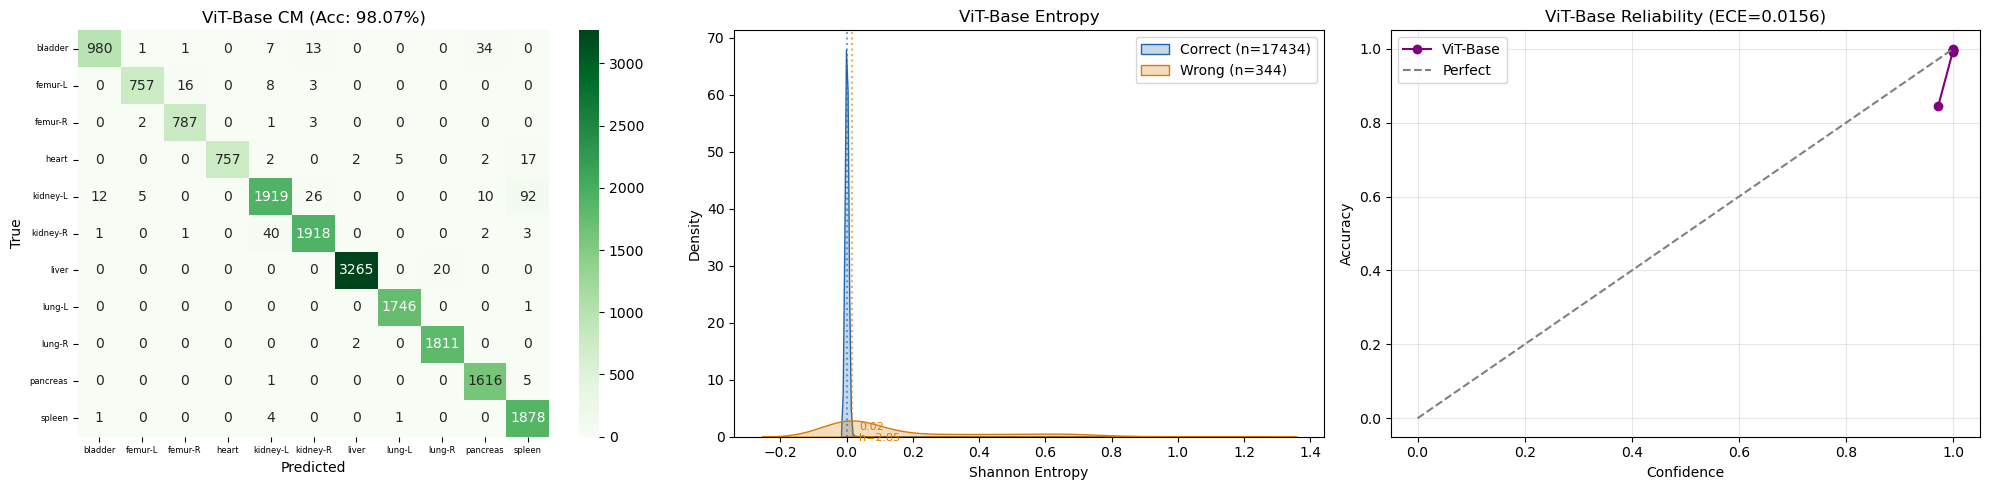


EVALUATION: EfficientNetV2M

--- Comprehensive Metrics ---
  Accuracy: 0.9710
  AUC_macro: 0.9991
  AUC_weighted: 0.9993
  Precision_macro: 0.9682
  Precision_weighted: 0.9721
  Recall_macro: 0.9687
  Recall_weighted: 0.9710
  F1_macro: 0.9676
  F1_weighted: 0.9707
  PR_AUC_macro: 0.9942
  PR_AUC_weighted: 0.9952
  Log_Loss: 0.1213

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9383    0.9402    0.9392      1036
     femur-L     0.9744    0.9235    0.9483       784
     femur-R     0.9175    0.9962    0.9553       793
       heart     1.0000    0.9796    0.9897       785
    kidney-L     0.9861    0.8580    0.9176      2064
    kidney-R     0.9431    0.9873    0.9647      1965
       liver     0.9960    0.9957    0.9959      3285
      lung-L     0.9949    0.9977    0.9963      1747
      lung-R     0.9923    0.9956    0.9939      1813
    pancreas     0.9895    0.9864    0.9880      1622
      spleen     0.9182    0.9952    0.

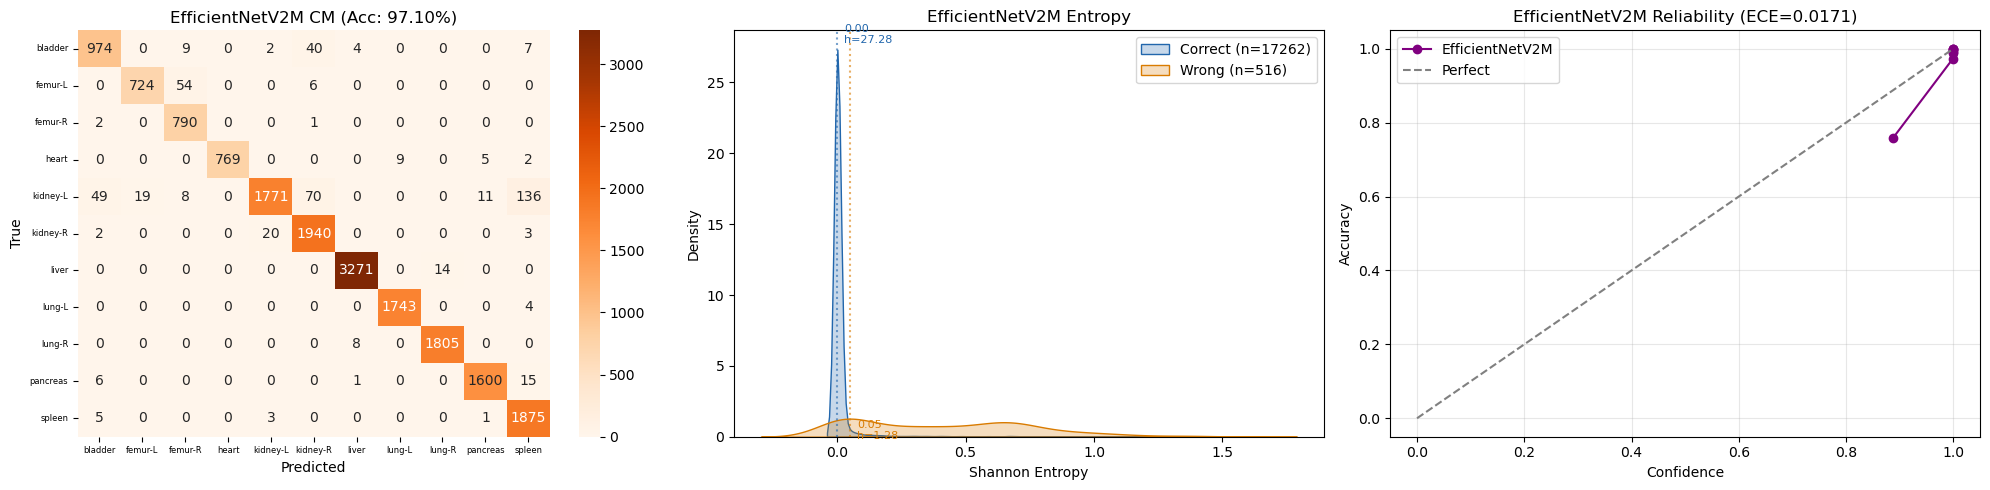


EVALUATION: InceptionResNetV2

--- Comprehensive Metrics ---
  Accuracy: 0.9722
  AUC_macro: 0.9993
  AUC_weighted: 0.9992
  Precision_macro: 0.9714
  Precision_weighted: 0.9722
  Recall_macro: 0.9707
  Recall_weighted: 0.9722
  F1_macro: 0.9709
  F1_weighted: 0.9721
  PR_AUC_macro: 0.9939
  PR_AUC_weighted: 0.9942
  Log_Loss: 0.1332

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9491    0.9537    0.9514      1036
     femur-L     0.9669    0.9694    0.9682       784
     femur-R     0.9803    0.9433    0.9614       793
       heart     0.9936    0.9924    0.9930       785
    kidney-L     0.9304    0.9070    0.9185      2064
    kidney-R     0.9676    0.9430    0.9552      1965
       liver     0.9991    0.9921    0.9956      3285
      lung-L     0.9989    0.9994    0.9991      1747
      lung-R     0.9858    0.9989    0.9923      1813
    pancreas     0.9770    0.9932    0.9850      1622
      spleen     0.9369    0.9851    

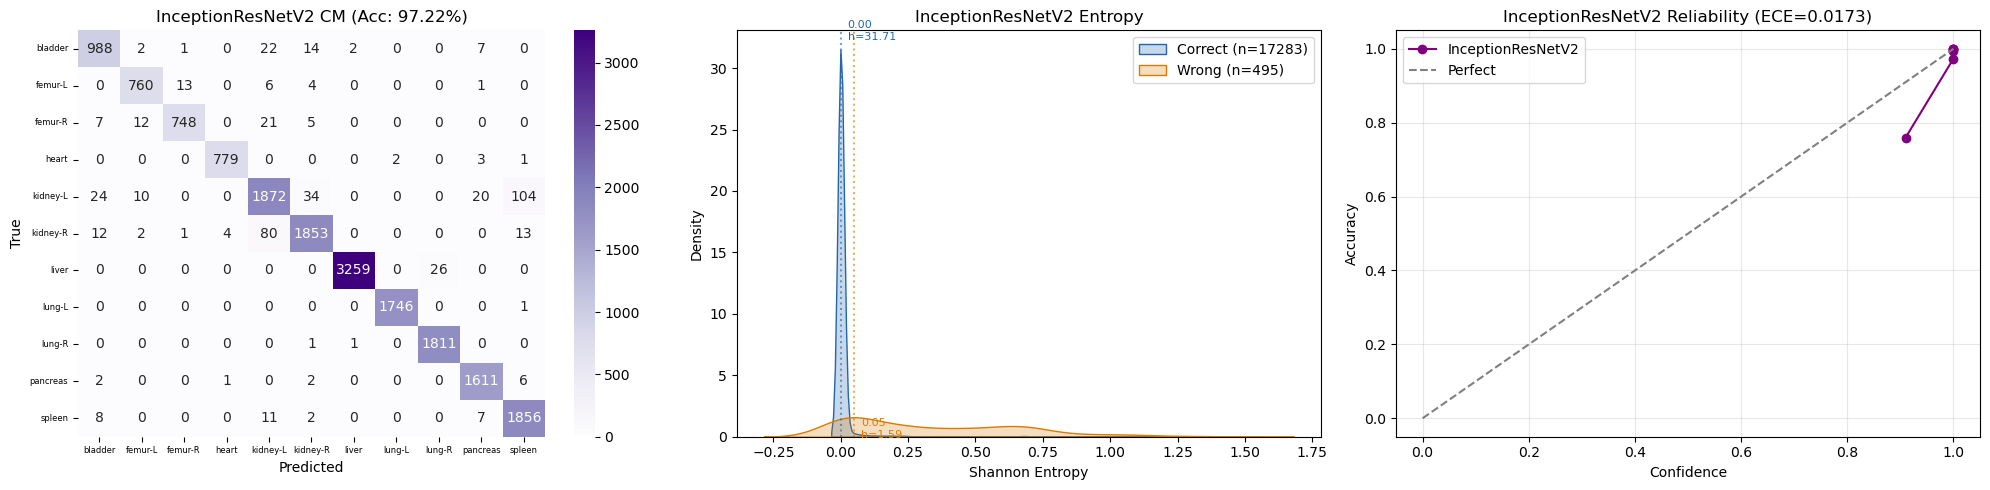


EVALUATION: SoftVoting

--- Comprehensive Metrics ---
  Accuracy: 0.9857
  AUC_macro: 0.9998
  AUC_weighted: 0.9998
  Precision_macro: 0.9864
  Precision_weighted: 0.9859
  Recall_macro: 0.9851
  Recall_weighted: 0.9857
  F1_macro: 0.9857
  F1_weighted: 0.9857
  PR_AUC_macro: 0.9983
  PR_AUC_weighted: 0.9983
  Log_Loss: 0.0487

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9883    0.9759    0.9820      1036
     femur-L     0.9935    0.9796    0.9865       784
     femur-R     0.9851    0.9975    0.9912       793
       heart     1.0000    0.9745    0.9871       785
    kidney-L     0.9697    0.9462    0.9578      2064
    kidney-R     0.9897    0.9771    0.9834      1965
       liver     1.0000    0.9927    0.9963      3285
      lung-L     0.9943    0.9994    0.9969      1747
      lung-R     0.9869    1.0000    0.9934      1813
    pancreas     0.9963    0.9969    0.9966      1622
      spleen     0.9470    0.9968    0.9713 

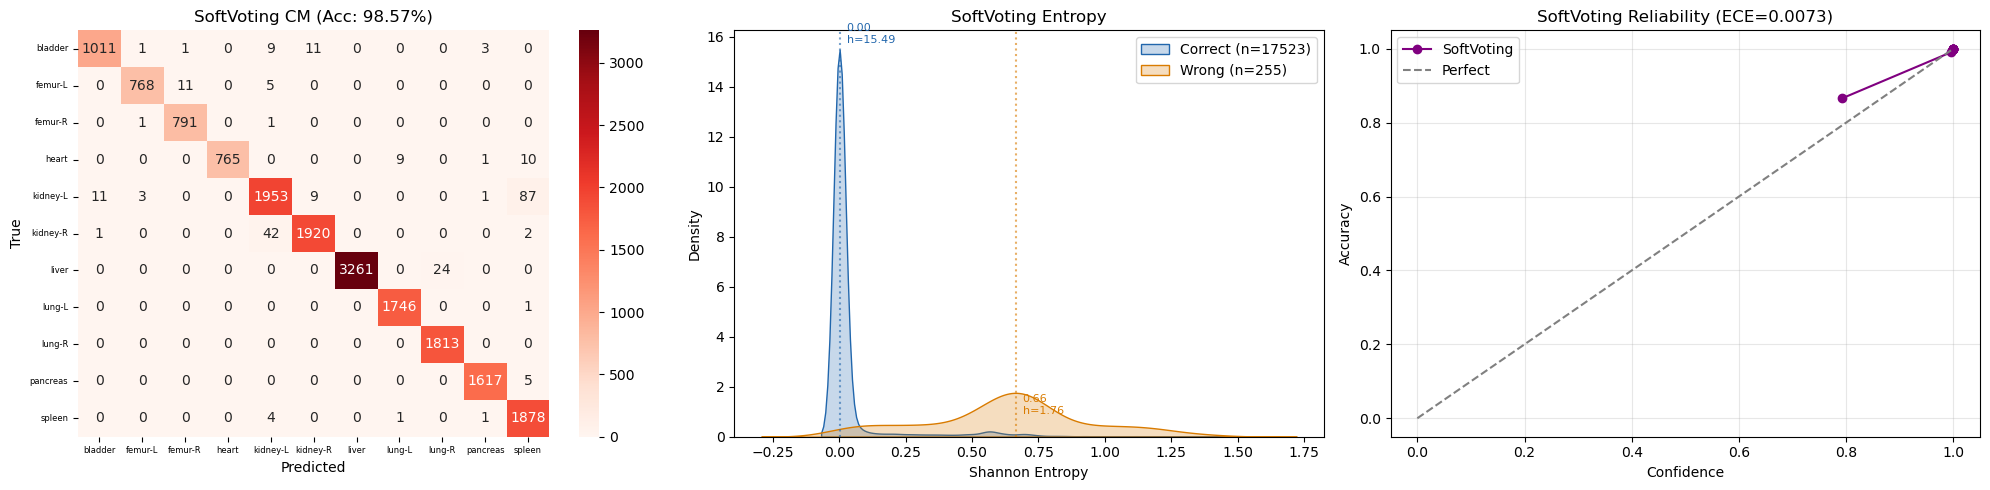


EVALUATION: RigorousStacking

--- Comprehensive Metrics ---
  Accuracy: 0.9855
  AUC_macro: 0.9989
  AUC_weighted: 0.9987
  Precision_macro: 0.9864
  Precision_weighted: 0.9857
  Recall_macro: 0.9850
  Recall_weighted: 0.9855
  F1_macro: 0.9856
  F1_weighted: 0.9855
  PR_AUC_macro: 0.9956
  PR_AUC_weighted: 0.9955
  Log_Loss: 0.1262

--- Classification Report ---
              precision    recall  f1-score   support

     bladder     0.9873    0.9739    0.9806      1036
     femur-L     0.9974    0.9770    0.9871       784
     femur-R     0.9851    0.9975    0.9912       793
       heart     1.0000    0.9783    0.9891       785
    kidney-L     0.9587    0.9564    0.9576      2064
    kidney-R     0.9922    0.9679    0.9799      1965
       liver     1.0000    0.9927    0.9963      3285
      lung-L     0.9960    0.9994    0.9977      1747
      lung-R     0.9869    1.0000    0.9934      1813
    pancreas     0.9866    0.9982    0.9923      1622
      spleen     0.9605    0.9936    0

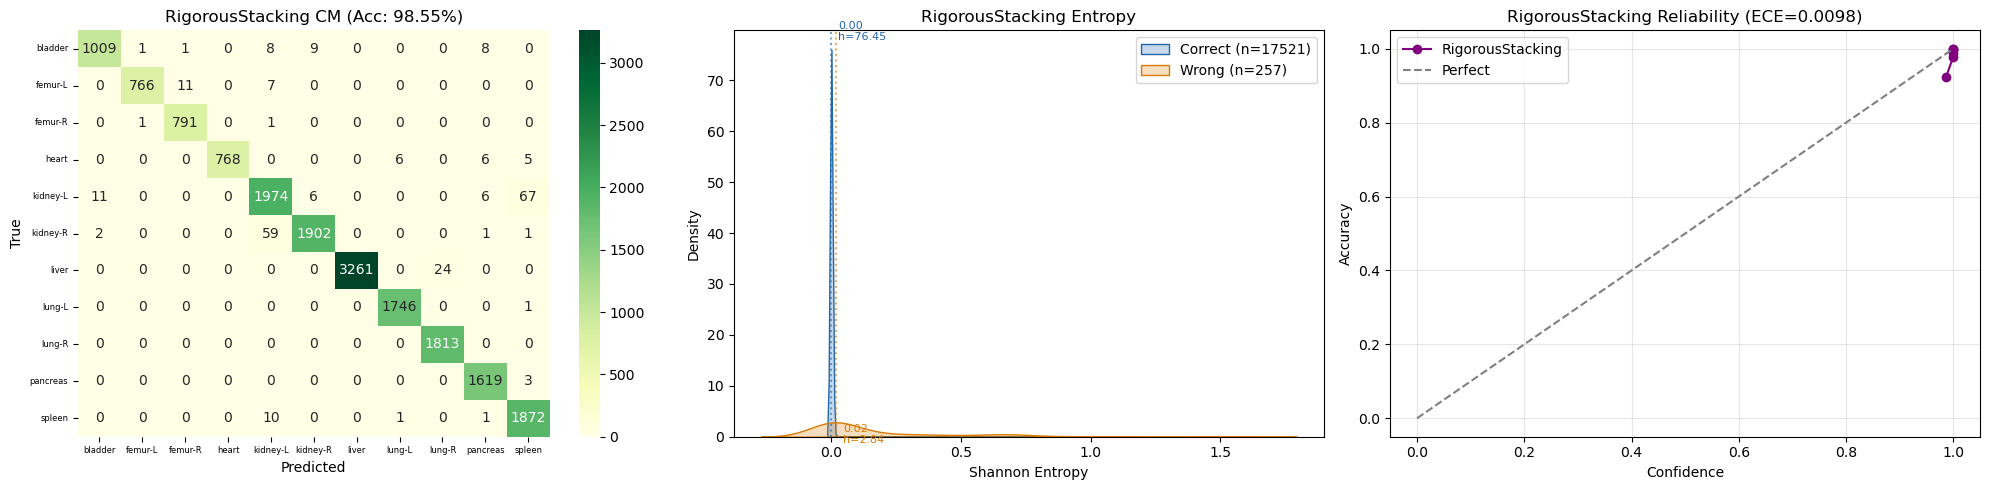

In [8]:
COLORS = {
    'ConvNeXtBase': 'Blues', 'ViT-Base': 'Greens',
    'EfficientNetV2M': 'Oranges', 'InceptionResNetV2': 'Purples',
    'SoftVoting': 'Reds', 'RigorousStacking': 'YlGn'
}

all_results = {}
all_metrics_list = []

# Build complete predictions dict
all_probs = dict(test_preds)
all_probs['SoftVoting'] = soft_voting_probs
all_probs['RigorousStacking'] = stacking_probs

for model_name in INDIVIDUAL_MODELS + ['SoftVoting', 'RigorousStacking']:
    res = evaluate_model(all_probs[model_name], y_true_flat, y_true_cat,
                         model_name, CLASS_NAMES, CLASS_NAMES_4CM, color=COLORS[model_name])
    all_results[model_name] = res
    all_metrics_list.append(res['metrics'])

## Summary Tables

In [9]:
print(f"\n{'='*90}\nFINAL COMPARISON: {DATASET.upper()}\n{'='*90}")

summary_df = pd.DataFrame(all_metrics_list)
print("\n--- Full Metrics Comparison ---")
print(summary_df.to_string(index=False))

summary_df.to_csv(f"{OUTPUT_DIR}/{DATASET}_summary_metrics.csv", index=False)

compact = summary_df[['Model', 'Accuracy', 'AUC_macro', 'F1_macro',
                       'Precision_macro', 'Recall_macro', 'PR_AUC_macro']].copy()
compact.columns = ['Model', 'Accuracy', 'AUC', 'F1', 'Precision', 'Recall', 'PR-AUC']
print("\n--- Compact Table for Paper ---")
print(compact.to_string(index=False))
compact.to_csv(f"{OUTPUT_DIR}/{DATASET}_compact_metrics.csv", index=False)


FINAL COMPARISON: ORGANAMNIST

--- Full Metrics Comparison ---
            Model  Accuracy  AUC_macro  AUC_weighted  Precision_macro  Precision_weighted  Recall_macro  Recall_weighted  F1_macro  F1_weighted  PR_AUC_macro  PR_AUC_weighted  Log_Loss
     ConvNeXtBase  0.972550   0.999398      0.999163         0.975115            0.973209      0.968952         0.972550  0.971621     0.972557      0.996025         0.995559  0.109484
         ViT-Base  0.980650   0.998925      0.998711         0.981350            0.980923      0.978132         0.980650  0.979529     0.980590      0.993697         0.993108  0.144758
  EfficientNetV2M  0.970975   0.999099      0.999286         0.968220            0.972051      0.968679         0.970975  0.967639     0.970669      0.994207         0.995208  0.121251
InceptionResNetV2  0.972157   0.999305      0.999241         0.971423            0.972244      0.970674         0.972157  0.970921     0.972072      0.993904         0.994171  0.133161
       Soft

## Publication Figure

In [10]:

ROW_LETTERS = list("abcdef")
CORRECT_COLOR_FIG = "#2166AC"
WRONG_COLOR_FIG = "#D97B00"

MODELS_FIG = [
    ("ConvNeXtBase",      "ConvNeXt-Base",      "Oranges", "darkorange"),
    ("ViT-Base",          "ViT-Base",           "Oranges", "darkorange"),
    ("EfficientNetV2M",   "EfficientNetV2-M",   "Oranges", "darkorange"),
    ("InceptionResNetV2", "InceptionResNetV2",  "Oranges", "darkorange"),
    ("SoftVoting",        "Soft Voting",        "Blues",   "#2166AC"),
    ("RigorousStacking",  "Rigorous Stacking",  "Greens",  "#1B7837"),
]

SHOW_PEAK_MARKERS = False  # Set True to add peak lines on entropy plots in pub figure


def plot_row_pub(fig, gs_row, model_key, cmap, line_color, row_idx, font_scale=1.0):
    probs = all_probs[model_key]
    y_pred_row = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true_flat, y_pred_row)
    letter = ROW_LETTERS[row_idx]

    # Panel (1): Confusion Matrix
    ax0 = fig.add_subplot(gs_row[0])
    cm = confusion_matrix(y_true_flat, y_pred_row)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax0, cbar=False,
                annot_kws={"size": 5.0 * font_scale}, linewidths=0.08,
                xticklabels=np.arange(n_classes), yticklabels=np.arange(n_classes))
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
    ax0.set_xlabel("Predicted Label")
    ax0.set_ylabel("True Label")
    ax0.tick_params(axis="both", pad=1)
    ax0.set_title(f"{letter}(1)   Acc = {acc:.2%}",
                  fontsize=7 * font_scale, fontweight="bold", loc="left", pad=3)

    # Panel (2): Entropy Distribution (with optional peak markers)
    ax1 = fig.add_subplot(gs_row[1])
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct = (y_pred_row == y_true_flat)
    sns.kdeplot(entropy[correct], fill=True, color=CORRECT_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Correct", linewidth=0.6)
    sns.kdeplot(entropy[~correct], fill=True, color=WRONG_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Incorrect", linewidth=0.6)
    
    if SHOW_PEAK_MARKERS and (~correct).sum() > 0:
        # Use the FIXED peak detection for visualization
        analysis = analyze_entropy_peaks(entropy[correct], entropy[~correct],
                                         f"Fig_{model_key}", n_points=500)
        if analysis:
            # Mark top peak only for each distribution to keep figure clean
            if analysis['peaks_correct_x']:
                ax1.axvline(analysis['peaks_correct_x'][0], color=CORRECT_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
            if analysis['peaks_wrong_x']:
                ax1.axvline(analysis['peaks_wrong_x'][0], color=WRONG_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
    
    ax1.set_xlabel("Entropy")
    ax1.set_ylabel("Density")
    ax1.legend(loc="upper right", frameon=False)
    ax1.tick_params(axis="both", pad=1)
    for spine in ax1.spines.values():
        spine.set_linewidth(0.4)
    ax1.set_title(f"{letter}(2)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)

    # Panel (3): Reliability Diagram
    ax2 = fig.add_subplot(gs_row[2])
    is_correct = correct.astype(int)
    conf = np.max(probs, axis=1)
    p_true, p_pred = calibration_curve(is_correct, conf, n_bins=10, strategy="quantile")
    ax2.plot(p_pred, p_true, marker="o", markersize=1.5,
             lw=0.7, color=line_color, clip_on=False)
    ax2.plot([0, 1], [0, 1], "--", color="gray", lw=0.6)
    ax2.set_xlabel("Confidence")
    ax2.set_ylabel("Accuracy")
    ax2.set_xlim(-0.05, 1.05)
    ax2.set_ylim(-0.05, 1.05)
    ax2.tick_params(axis="both", pad=1)
    for spine in ax2.spines.values():
        spine.set_linewidth(0.4)
    ax2.set_title(f"{letter}(3)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)


def generate_publication_figure(output_format='png', dpi=1200):
    if output_format == 'png':
        fig_w, fig_h = 6.85, 8.94
        font_scale = 1.0
        font_size = 7
    else:
        fig_w, fig_h = 18, 23.5
        font_scale = 1.6
        font_size = 11
    
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size - 0.5,
        "xtick.labelsize": font_size - 1.5,
        "ytick.labelsize": font_size - 1.5,
        "legend.fontsize": font_size - 1.5,
        "axes.linewidth": 0.4 * font_scale,
        "xtick.major.width": 0.4 * font_scale,
        "ytick.major.width": 0.4 * font_scale,
    })
    
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    gs_outer = gridspec.GridSpec(
        6, 1, figure=fig,
        hspace=0.55 if output_format == 'png' else 0.35,
        top=0.98, bottom=0.03 if output_format == 'png' else 0.02,
        left=0.10 if output_format == 'png' else 0.07,
        right=0.98
    )
    
    for i, (m_key, _, cmap, color) in enumerate(MODELS_FIG):
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[i], wspace=0.28)
        plot_row_pub(fig, gs_inner, m_key, cmap, color, i, font_scale)
    
    ext = 'png' if output_format == 'png' else 'tif'
    output_path = f"{OUTPUT_DIR}/Fig{FIGURE_NUMBER}.{ext}"
    plt.savefig(output_path, bbox_inches="tight",
                pad_inches=0.05 if output_format == 'png' else 0.1,
                dpi=dpi, format=output_format,
                metadata={"Software": "matplotlib"} if output_format == 'png' else None)
    plt.close(fig)
    print(f"Saved {output_path}")
    return output_path

png_path = generate_publication_figure(output_format='png', dpi=1200)
tiff_path = generate_publication_figure(output_format='tiff', dpi=600)

print(f"\n✓ Publication figures:")
print(f"  PNG (1200 DPI): {png_path}")
print(f"  TIFF (600 DPI): {tiff_path}")

Saved ./organamnist_results/Fig6.png
Saved ./organamnist_results/Fig6.tif

✓ Publication figures:
  PNG (1200 DPI): ./organamnist_results/Fig6.png
  TIFF (600 DPI): ./organamnist_results/Fig6.tif
